In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:

print("GPU dostupno:", torch.cuda.is_available())  
print("Broj GPU:", torch.cuda.device_count())
print("Ime GPU:", torch.cuda.get_device_name(0)) 


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print("Koristim:", device)  


x = torch.tensor([1.0, 2.0])
x = x.to(device)
print("Tenzor je na:", x.device)  

GPU dostupno: True
Broj GPU: 1
Ime GPU: NVIDIA GeForce GTX 1660 SUPER
Koristim: cuda:0
Tenzor je na: cuda:0


In [3]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.ImageFolder('dataset/train', transform=transform)
test_data = datasets.ImageFolder('dataset/test', transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [4]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)#Ulaz kanalai, izlaz, velicina filtera
        self.pool = nn.MaxPool2d(2, 2) #kernel, stride
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.fc1 = nn.Linear(64 * 30 * 30, 128)#vektor velicina, ide usloj sa x neurona
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 30 * 30)# "Spljoštava" 3D tenzor u 1D vektor

        x = torch.relu(self.fc1(x))#Aktivacija za prvi potpuno povezani sloj
        x = self.sigmoid(self.fc2(x))#daje verovatnocu
        return x

model = CNNModel().to(device)

In [5]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [6]:
num_epochs = 10
train_losses = []
test_losses = []

In [ ]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad() # Resetuje gradijente (inače se sabiraju)
        outputs = model(images)#Model obrađuje slike i daje predikcije
        loss = criterion(outputs, labels)
        loss.backward() # Izračuna gradijente (derivate) svih parametara
        optimizer.step() # Ažurira parametre koristeći gradijente
        
        running_loss += loss.item()
    train_losses.append(running_loss/len(train_loader))
    

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
    test_losses.append(test_loss/len(test_loader))
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}")

Epoch [1/10], Train Loss: 0.6273, Test Loss: 0.6615
Epoch [2/10], Train Loss: 0.4930, Test Loss: 0.5929
Epoch [3/10], Train Loss: 0.4248, Test Loss: 0.5716
Epoch [4/10], Train Loss: 0.3635, Test Loss: 0.5891
Epoch [5/10], Train Loss: 0.2933, Test Loss: 0.6542
Epoch [6/10], Train Loss: 0.2103, Test Loss: 0.8141
Epoch [7/10], Train Loss: 0.1274, Test Loss: 1.0572
Epoch [8/10], Train Loss: 0.0735, Test Loss: 1.2358
Epoch [9/10], Train Loss: 0.0360, Test Loss: 1.5067
Epoch [10/10], Train Loss: 0.0200, Test Loss: 2.3444


In [ ]:
torch.save(model.state_dict(), 'model/pas_macka_model6.pth')


In [9]:
model.load_state_dict(torch.load("model/pas_macka_model6.pth", map_location=torch.device('cpu'), weights_only=True))


<All keys matched successfully>

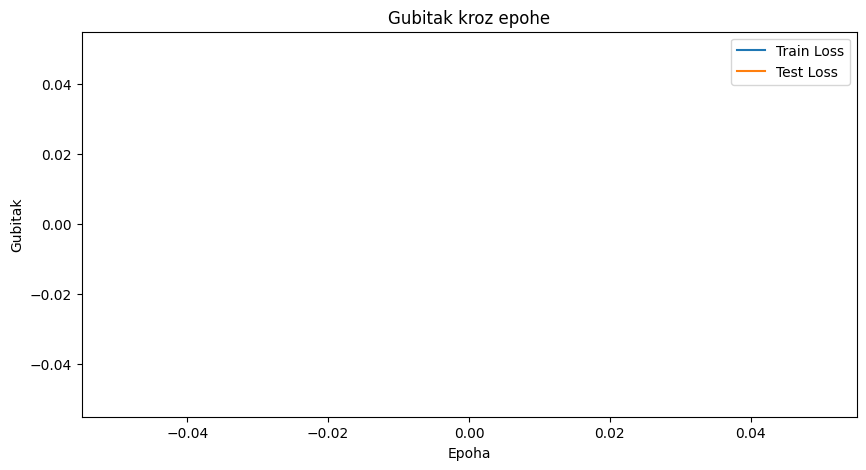

In [13]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Gubitak kroz epohe')
plt.xlabel('Epoha')
plt.ylabel('Gubitak')
plt.legend()
plt.show()

In [33]:
from PIL import Image

def predikcija_putanja(putanja):
    model.eval()
    img = Image.open(putanja)
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        prediction = torch.round(output)
    
    if prediction == 1:
        print("Model predicts: Dog ")
    else:
        print("Model predicts: Cat ")

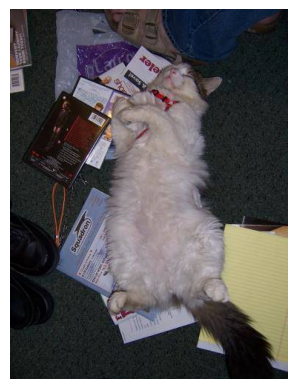

Model predicts: Cat 


In [34]:
putanja = 'dataset/test/1.jpg'

plt.imshow(Image.open(putanja))
plt.axis('off')
plt.show()
predikcija_putanja(putanja)
